# Lets take a deeper look at the KDE values

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [3]:
def fhat(X, h=0.15):
    X = np.asarray(X, dtype=float)

    n, d = X.shape

    m = d - 1

    # Pairwise differences normalized by h: u_ij = (x_j - x_i) / h

    """X[None, :, :] changes shape from (n,d) to (1,n,d)
    X[:, None, :] changes shape from (n,d) to (n,1,d)
    Numpy can then broadcast them to together creating (1,n,d) - (n,1,d) = (n,n,d)
    so each pair (i,j) diff[i,j,:] = (x_j - x_i) / h.
    So this fixes point x_i compares it to point x_j and subtracts coord by coord and then divides by h.
    diff stores every scaled difference vector between every pair of points.
    so diff is (n=first axis i,n = second axis j,d = coordinates). 
    """
    
    diff = (X[None, :, :] - X[:, None, :]) / h   # (n, n, d)
    D = np.linalg.norm(diff, axis = 2) # (n,n) axis 2 holds coordinates of the distance vector between x_i and x_j and summing across it collapses the broadcasted diff into the distance matrix divided by h

    r2 = D ** 2   

    # Gaussian kernel in R^m
    K = np.exp(-0.5 * r2) / ((2 * np.pi) ** (m / 2))  # (n, n) 

    # KDE at each x_i
    f = K.sum(axis=1) / (n * (h ** m))   # (n,)
    return f

def weighted_distance_matrix_kde(X, h=0.15):

    n, d = X.shape
    m = d - 1

    D = np.linalg.norm(X[None, :, :] - X[:, None, :], axis = 2)

    f = fhat(X, h=h)
    f = np.maximum(f, 1e-12) # guard against zero density         
    s = f ** (1.0 / m)  # (n,)

    si = s[:, None]
    sj = s[None, :]

    scale = (2.0 * si * sj) / (si + sj)
    
    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f, scale

def hemisphere_biased_hypersphere(
    n_points,
    d,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    seed=None,
    shuffle=True,
):
    # p = fraction of points in the hemisphere
    # {x : <x - center, direction> >= 0}

    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    rng = np.random.default_rng(seed)

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0

    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    def sample_uniform_sphere(m):
        X = rng.normal(size=(m, d))
        norms = np.linalg.norm(X, axis=1, keepdims=True)

        while np.any(norms == 0):
            bad = norms[:, 0] == 0
            X[bad] = rng.normal(size=(bad.sum(), d))
            norms[bad] = np.linalg.norm(X[bad], axis=1, keepdims=True)

        return X / norms

    n_side = int(round(p * n_points))
    n_other = n_points - n_side

    # sample points for the chosen hemisphere
    X_side = sample_uniform_sphere(n_side)
    dots_side = X_side @ direction
    X_side[dots_side < 0] *= -1.0

    # sample points for the opposite hemisphere
    X_other = sample_uniform_sphere(n_other)
    dots_other = X_other @ direction
    X_other[dots_other > 0] *= -1.0

    X = np.vstack([X_side, X_other])

    if shuffle:
        rng.shuffle(X, axis=0)

    X *= r

    if center is not None:
        center = np.asarray(center, dtype=float)
        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")
        X += center

    return X

def hypersphere_surface_area(d, r=1.0):
    if d < 2:
        raise ValueError("d must be at least 2")
    if r <= 0:
        raise ValueError("r must be positive")

    log_area = (
        math.log(2.0)
        + 0.5 * d * math.log(math.pi)
        + (d - 1) * math.log(r)
        - math.lgamma(d / 2.0)
    )
    return math.exp(log_area)

def hemisphere_biased_hypersphere_pdf(
    C,
    p = 0.8,
    r = 1.0,
    center = None,
    direction = None,
    tol = 1e-8,
):
    C = np.asarray(C, dtype=float)

    if C.ndim != 2:
        raise ValueError("C must have shape (n_points, d)")

    n_points, d = C.shape

    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    if center is None:
        center = np.zeros(d)
    center = np.asarray(center, dtype=float)
    if center.shape != (d,):
        raise ValueError(f"center must have shape ({d},)")

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0
    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    shifted = C - center
    radii = np.linalg.norm(shifted, axis=1)
    on_sphere = np.abs(radii - r) <= tol

    dots = shifted @ direction
    area = hypersphere_surface_area(d, r)

    pdf_vals = np.zeros(n_points, dtype=float)


    pdf_vals[on_sphere & (dots >= 0)] = 2.0 * p / area
    pdf_vals[on_sphere & (dots < 0)] = 2.0 * (1.0 - p) / area

    return pdf_vals

def weighted_distance_matrix_pdf(
    X,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    d_manifold=1,
    tol=1e-8,
):
  
    X = np.asarray(X, dtype=float)

    D = np.linalg.norm(X[None, :, :] - X[:, None, :], axis = 2)


    f = hemisphere_biased_hypersphere_pdf(
        X,
        p=p,
        r=r,
        center=center,
        direction=direction,
        tol=tol,
    )

    f = np.maximum(f, 1e-12)   # guard against zero density
    s = f ** (1.0 / d_manifold)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    scale = ( 2.0 * si * sj) / (si + sj)

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f, scale


In [4]:
C = hemisphere_biased_hypersphere(
    n_points= 100,
    d = 2,
    p = 0.8,
    r = 1.0,
    direction = [1,0],
    seed = 123,
)

# What are the pdf and scale values for this specific shape?



C lies on the unit circle $S^1 \subset \mathbb{R}^2$ with 80 points in the hemisphere where the first coordinate is nonnegative and 20 points in the opposite hemisphere. This is because the default direction is $(1,0)$. 

## pdf

The surface area of $S^1$ with radius $1$ is

$$A = 2\pi.$$

So the raw pdf for this specific circle is

$$f
_C(c_i) = 
\begin{cases}
\dfrac{2p}{2\pi} = \dfrac{0.8}{\pi}, & c_{i,1} \ge 0, \\
\dfrac{2(1-p)}{2\pi} = \dfrac{0.2}{\pi}, & c_{i,1} < 0
\end{cases} 
$$

Numerically, the only two raw pdf values are then

$$
\frac{0.8}{\pi} \approx 0.25465,
\qquad
\frac{0.2}{\pi} \approx 0.06366.
$$

So for this samples $C$, we should expect 80 points equal to $\dfrac{0.8}{\pi} \approx 0.25465$ and 20 points equal to $\dfrac{0.2}{\pi} \approx 0.06366$ in some shuffled order.

## scale

Each scale value is
$$
s_i = f(x_i)^{1/m}
$$

with $m = d - 1.$

Therefore, the scale matrix is

$$
s_{ij}
=
\frac{2s_i s_j}{s_i+s_j}
=
\frac{
2\,f(x_i)^{1/m}f(x_j)^{1/m}
}{
f(x_i)^{1/m}+f(x_j)^{1/m}
}
=
\boxed{
\frac{1}{
\frac{1}{2}\left(f(x_i)^{-1/m}+f(x_j)^{-1/m}\right)
}
}.
$$

There are three cases for the scale value:
$$
s_{ij}=
\begin{cases}
\dfrac{0.8}{\pi}, & \text{if both } x_i,x_j \text{ are in the high-density hemisphere},\\[8pt]
\dfrac{0.32}{\pi}, & \text{if one is high-density and the other is low-density},\\[8pt]
\dfrac{0.2}{\pi}, & \text{if both } x_i,x_j \text{ are in the low-density hemisphere}.
\end{cases}
$$

Numerically, these are

$$
\boxed{
\left\{
\frac{0.2}{\pi},\;
\frac{0.32}{\pi},\;
\frac{0.8}{\pi}
\right\}
\approx
\{0.06366,\;0.10186,\;0.25465\}.
}
$$

In [5]:
_, f_pdf, scale_pdf = weighted_distance_matrix_pdf(
    C,
    p = 0.8,
    r = 1.0,
)

print(np.unique(f_pdf), "\n")
print(np.unique(scale_pdf))

[0.06366198 0.25464791] 

[0.06366198 0.10185916 0.25464791]


# What are the expected kde and scale values for this specific shape?

## KDE

For the current KDE construction, the pointwise KDE at a sample point $x_i$ is

$$
\hat f_i
=
\frac{1}{n h^m (2\pi)^{m/2}}
\sum_{j=1}^n
\exp\!\left(
-\frac12
\left\|
\frac{x_j-x_i}{h}
\right\|^2
\right)
$$

with $m = d - 1.$

Currently,

$$
n=100,\qquad h=0.15,\qquad m=d-1=1,
$$

which becomes

$$
\hat f(x_i)
=
\frac{1}{100\cdot 0.15\sqrt{2\pi}}
\sum_{j=1}^{100}
\exp\!\left(
-\frac{\|x_j-x_i\|^2}{2(0.15)^2}
\right).
$$

Then the KDE-based pairwise scale is

$$
s_{ij}^{\mathrm{KDE}}
=
\frac{2\,\hat f(x_i)^{1/m}\hat f(x_j)^{1/m}}
{\hat f(x_i)^{1/m}+\hat f(x_j)^{1/m}}.
$$

Since $m = 1$ here, this simplifies to

$$
\boxed{
s_{ij}^{\mathrm{KDE}}
=
\frac{2\,\hat f(x_i)\hat f(x_j)}{\hat f(x_i)+\hat f(x_j)}.
}
$$

Here there is not a fixed finite set of exact KDE values ahead of time. The values $\hat f(x_i)$ depend on the actual sampled neighbors around each point, so in general:

$$
\hat f(x_1), \dots, \hat f(x_n)
$$

are all slightly different, and therefore

$$
s_{ij}^{\mathrm{KDE}}
$$

also takes many different values.

What we should expect is that

$$
\hat f(x_i) \approx \frac{0.8}{\pi} \approx 0.25465
\quad\text{for points well inside the dense hemisphere},
$$

$$
\hat f(x_i) \approx \frac{0.2}{\pi} \approx 0.06366
\quad\text{for points well inside the sparse hemisphere},
$$

and for points near the hemisphere boundary,

$$
\hat f(x_i)
$$

should lie somewhere in between because the Gaussian kernel smooths across nearby points from both sides.

So corresponding KDE scale values should be approximately

$$
s_{ij}^{\mathrm{KDE}}
\approx
\begin{cases}
\dfrac{0.8}{\pi}, & \text{if both points are deep in the dense side},\\[8pt]
\dfrac{0.32}{\pi}, & \text{if one is dense-side and one is sparse-side},\\[8pt]
\dfrac{0.2}{\pi}, & \text{if both points are deep in the sparse side},
\end{cases}
$$

that is,

$$
\boxed{
\left\{
\frac{0.2}{\pi},\;
\frac{0.32}{\pi},\;
\frac{0.8}{\pi}
\right\}
\approx
\{0.06366,\;0.10186,\;0.25465\}
}
$$

but only as an approximation to the large-sample / away-from boundary behavior, not as exact values for every entry.



In [6]:
_, f_kde, scale_kde = weighted_distance_matrix_kde(
    C,
    h = 0.342,
)

print(np.unique(f_kde), "\n")
print(np.unique(scale_kde))

[0.05820959 0.06030131 0.06169974 0.06171926 0.06208189 0.06239692
 0.06243783 0.06476057 0.06584305 0.06758518 0.06814697 0.06889745
 0.07029293 0.07675015 0.10528293 0.10744475 0.11678608 0.117452
 0.12810692 0.15215859 0.15328857 0.16319135 0.18081362 0.18181029
 0.18915574 0.19421899 0.1968054  0.20387252 0.20770215 0.21126652
 0.2196862  0.22062571 0.22431393 0.2278147  0.22893981 0.23378783
 0.23456684 0.23570813 0.23583792 0.23584995 0.23713747 0.23883069
 0.24180659 0.24602013 0.24663048 0.24775878 0.24786436 0.24821729
 0.24899317 0.24921303 0.24936872 0.24953696 0.24964835 0.24966018
 0.25113266 0.25145497 0.25162925 0.25219966 0.25238839 0.25570953
 0.25601702 0.25620198 0.25642694 0.25749832 0.25788173 0.25816675
 0.25818056 0.26031629 0.26075574 0.26101859 0.26154744 0.26175075
 0.26207955 0.26243079 0.26282893 0.26367663 0.26476608 0.26513996
 0.26771677 0.26776027 0.26814611 0.26980864 0.27674771 0.27887145
 0.27913168 0.27974639 0.28021656 0.28271185 0.28273044 0.282757

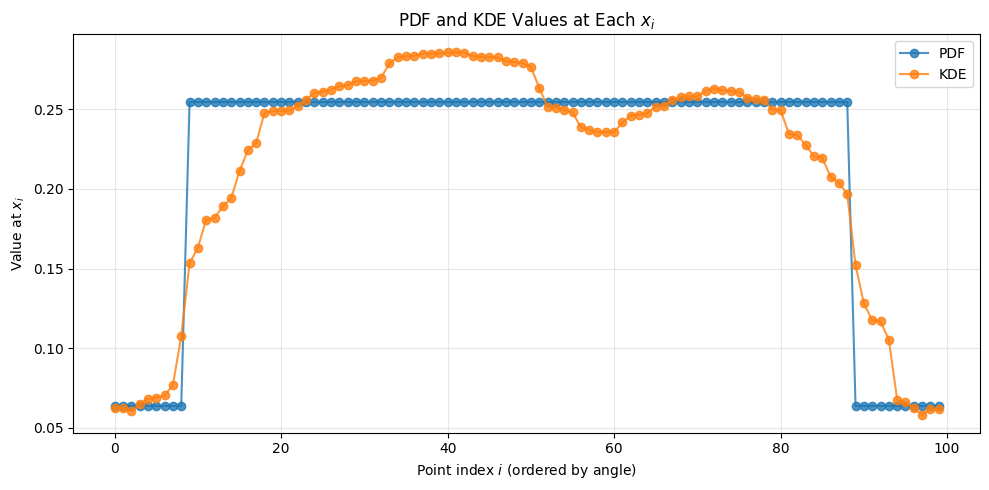

In [7]:
_, f_pdf, _ = weighted_distance_matrix_pdf(C, p=0.8, r=1.0)
_, f_kde, _ = weighted_distance_matrix_kde(C, h=0.342)

#points ordered around the circle instead of shuffled index order
theta = np.arctan2(C[:, 1], C[:, 0])
order = np.argsort(theta)

x_idx = np.arange(len(C))

plt.figure(figsize=(10, 5))
plt.plot(x_idx, f_pdf[order], 'o-', label='PDF', alpha=0.8)
plt.plot(x_idx, f_kde[order], 'o-', label='KDE', alpha=0.8)

plt.xlabel(r'Point index $i$ (ordered by angle)')
plt.ylabel(r'Value at $x_i$')
plt.title(r'PDF and KDE Values at Each $x_i$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

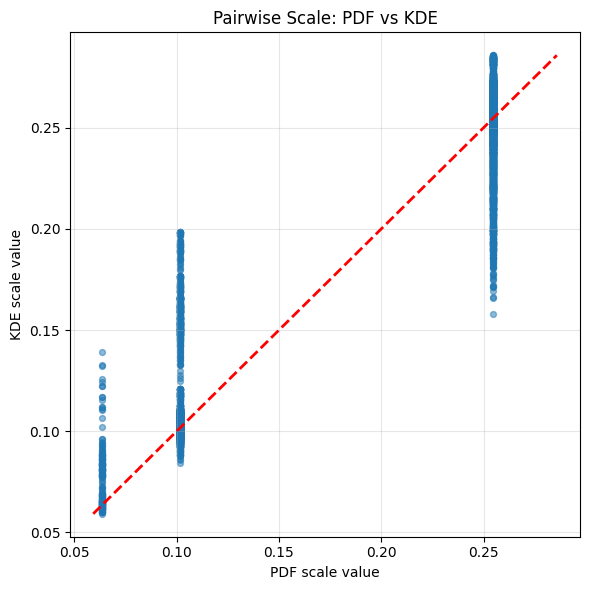

In [8]:
# Compute scales
_, _, scale_pdf = weighted_distance_matrix_pdf(
    C,
    p=0.8,
    r=1.0,
    direction=[1, 0],
)

_, _, scale_kde = weighted_distance_matrix_kde(
    C,
    h=0.342,
)

# Use only upper triangle, excluding diagonal
i, j = np.triu_indices_from(scale_pdf, k=1)

x = scale_pdf[i, j]
y = scale_kde[i, j]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=18)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=2)

plt.xlabel('PDF scale value')
plt.ylabel('KDE scale value')
plt.title('Pairwise Scale: PDF vs KDE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Observations

The scatter plot is plotting one points for each unordered pair $(i,j)$ with $i < j$, where

$$
x = s_{ij}^{\mathrm{PDF}},
\qquad
y = s_{ij}^{\mathrm{KDE}}.
$$

Since there are $n=100$ sample points and we use only the upper triangle excluding the original diagonal, the total number of plotted points is

$$
\binom{100}{2} = 4950.
$$

The reason the scatter plot shows three vertical bands is that the PDF-based scale only takes three possible values. In the current setting,

$$
s_{ij}^{\mathrm{PDF}}
\in
\left\{
\frac{0.2}{\pi},\;
\frac{0.32}{\pi},\;
\frac{0.8}{\pi}
\right\}
\approx
\{0.06366,\;0.10186,\;0.25465\}.
$$

These three values correspond to the three possible types of pairs:

$$
s_{ij}^{\mathrm{PDF}}=\frac{0.8}{\pi}
\quad\text{if both points lie in the high-density hemisphere,}
$$

$$
s_{ij}^{\mathrm{PDF}}=\frac{0.32}{\pi}
\quad\text{if one point lies in the high-density hemisphere and the other in the low-density hemisphere,}
$$

$$
s_{ij}^{\mathrm{PDF}}=\frac{0.2}{\pi}
\quad\text{if both points lie in the low-density hemisphere.}
$$

Because there are $80$ points in the high-density hemisphere and $20$ points in the low-density hemisphere, the numbers of each pair type are

$$
\binom{80}{2}=3160
\quad\text{high-high pairs,}
$$

$$
80\cdot 20=1600
\quad\text{high-low pairs,}
$$

$$
\binom{20}{2}=190
\quad\text{low-low pairs.}
$$

Thus the rightmost vertical band should contain $3160$ points, the middle band $1600$ points, and the leftmost band $190$ points. 

On the KDE side, the scale values are not restricted to only three constants. Instead they are computed from the pointwise KDE values by 

$$
s_{ij}^{\mathrm{KDE}}
=
\frac{2\hat f(x_i) \hat f(x_j)}{\hat f(x_i)+\hat f(x_j)},
$$

where

$$
\hat f(x_i)
=
\frac{1}{n h^m (2\pi)^{m/2}}
\sum_{j=1}^n
\exp\!\left(
-\frac12
\left\|
\frac{x_j-x_i}{h}
\right\|^2
\right).
$$

Because the KDE values $\hat f(x_i)$ vary from point to point, the quantities $s_{ij}^{\mathrm{KDE}}$ also vary from pair to pair. This is why each vertical PDF band spreads out vertically in the scatter plot.

The interpretation of the scatter is therefore:

$$
x = s_{ij}^{\mathrm{PDF}}
\quad\text{gives the ideal piecewise-constant scale,}
$$

$$
y = s_{ij}^{\mathrm{KDE}}
\quad\text{gives the estimated scale from the KDE.}
$$

If the KDE matched the PDF perfectly, then all points would lie exactly on the diagonal line

$$
y=x.
$$

If a cluster lies above the diagonal, then the KDE scale is larger than the PDF scale for that type of pair. If a cluster lies below the diagonal, then the KDE scale is smaller than the PDF scale for that type of pair.

In the present example, the low-density and mixed pairs are typically shifted upward relative to their PDF values, reflecting the fact that the Gaussian KDE smooths across the sharp boundary between the two hemispheres and therefore raises the estimated density on the sparse side.





Optimal h on this grid: 0.3421
Minimum MSE: 0.000926


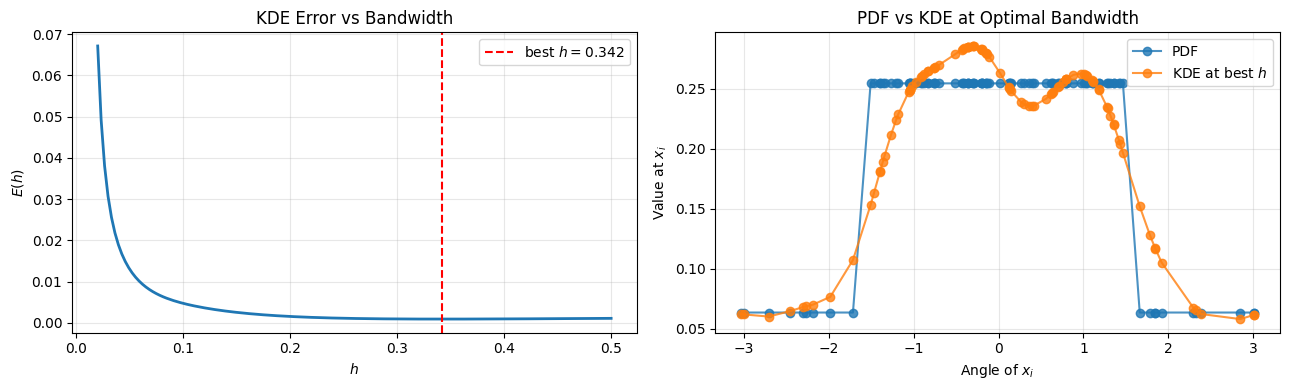

In [9]:
_, f_pdf, _ = weighted_distance_matrix_pdf(
    C,
    p=0.8,
    r=1.0,
    direction=[1, 0],
)

# Grid of bandwidths to try
hs = np.linspace(0.02, 0.50, 150)

errors = []

for h in hs:
    _, f_kde, _ = weighted_distance_matrix_kde(C, h=h)
    err = np.mean((f_kde - f_pdf) ** 2)   # MSE between KDE and exact PDF
    errors.append(err)

errors = np.array(errors)

# Best h on this grid
h_opt = hs[np.argmin(errors)]
print(f"Optimal h on this grid: {h_opt:.4f}")
print(f"Minimum MSE: {errors.min():.6f}")

# KDE at the chosen h
_, f_kde_opt, _ = weighted_distance_matrix_kde(C, h=h_opt)

# Order points around the circle for cleaner plotting
theta = np.arctan2(C[:, 1], C[:, 0])
order = np.argsort(theta)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Error as a function of h
ax[0].plot(hs, errors, lw=2)
ax[0].axvline(h_opt, color='red', linestyle='--', label=fr'best $h={h_opt:.3f}$')
ax[0].set_xlabel(r'$h$')
ax[0].set_ylabel(r'$E(h)$')
ax[0].set_title('KDE Error vs Bandwidth')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Compare PDF and KDE at the best h
ax[1].plot(theta[order], f_pdf[order], 'o-', label='PDF', alpha=0.8)
ax[1].plot(theta[order], f_kde_opt[order], 'o-', label=fr'KDE at best $h$', alpha=0.8)
ax[1].set_xlabel(r'Angle of $x_i$')
ax[1].set_ylabel(r'Value at $x_i$')
ax[1].set_title('PDF vs KDE at Optimal Bandwidth')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import ecc_vr as vr

def sample_wrapped_normal_hypersphere(
    n_points,
    d,
    sigma = 1,
    mean_direction = None,
    seed = None
):

    """
    Sample points on the unit hypersphere S^{dim-1} in R^dim
    using an isotropic wrapped normal distribution.

    sigma is the tangent-space standard deviation, in radians.

    """

    rng = np.random.default_rng(seed)

    if mean_direction is None:
        mu = np.zeros(d)
        mu[0] = 1
    else:
        mu = np.asarray(mean_direction, dtype = float)
        if mu.shape != (d,):
            raise ValueError
        mu = mu / np.linalg.norm(mu)
    
    Z = rng.normal(0.0, sigma, size = (n_points, d))

    # project normal noise onto tangent space at mu

    V = Z - (Z @ mu)[:, None] * mu[None, :]
    r = np.linalg.norm(V, axis =1, keepdims=True)

    U = np.zeros_like(V)
    nonzero = r[:, 0] > 0
    U[nonzero] = V[nonzero] / r[nonzero]

    #exponential map on unit sphere
    X = np.cos(r) * mu[None, :] + np.sin(r) * U 

    # floating point drift
    X = X / np.linalg.norm(X, axis = 1, keepdims = True)

    return X

def wrapped_normal_hypersphere_pdf_exact(
    X,
    sigma=0.35,
    mean_direction=None,
    K=5,
    eps=1e-12,
):
    n_points, d = X.shape
    m = d - 1

    if mean_direction is None:
        mu = np.zeros(d)
        mu[0] = 1.0
    else:
        mu = np.asarray(mean_direction, dtype=float)

    mu = mu / np.linalg.norm(mu)

    X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)

    dots = X_unit @ mu
    dots = np.clip(dots, -1.0, 1.0)

    theta = np.arccos(dots)
    sin_theta = np.sin(theta)

    const = (2.0 * np.pi * sigma**2) ** (-m / 2.0)

    f = np.zeros(n_points, dtype=float)

    for k in range(-K, K + 1):
        r = theta + 2.0 * np.pi * k

        gaussian_part = np.exp(-(r**2) / (2.0 * sigma**2))

        jacobian_part = np.ones_like(theta)
        mask = sin_theta > eps
        jacobian_part[mask] = np.abs(r[mask] / sin_theta[mask]) ** (m - 1)

        # At theta = 0, use limiting value for the k = 0 term.
        if k == 0:
            jacobian_part[~mask] = 1.0

        f += const * gaussian_part * jacobian_part

    return f

def weighted_distance_matrix_wrapped_normal_pdf(X, sigma = 0.35, mean_direction = None):
    
    D = vr.pairwise_dist(X)
    f = wrapped_normal_hypersphere_pdf_exact(
        X,
        sigma = sigma,
        mean_direction=mean_direction,
        K = 20
    )

    _, d = X.shape
    m = d - 1


    f = np.maximum(f, 1e-12)   # guard against zero density
    s = f ** (1.0 / m)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    scale = (2.0 * si * sj) / (si + sj)

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f, scale


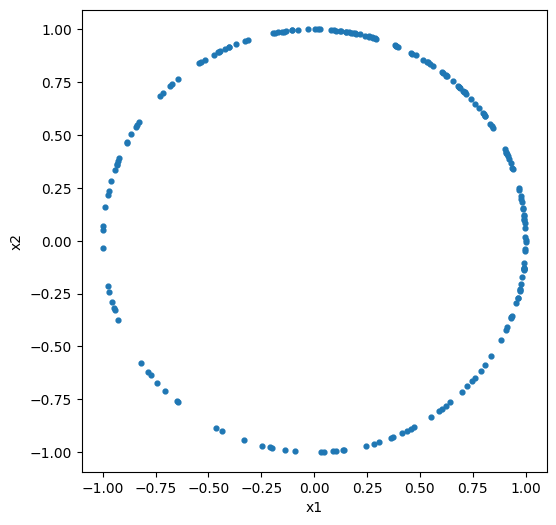

In [11]:
X = sample_wrapped_normal_hypersphere(
    n_points = 200,
    d = 2,
    sigma = 1.5,
    mean_direction=[1,1],
    seed=123,    
)

plt.figure(figsize = (6,6))
plt.scatter(X[:, 0], X[:,1], s = 12)
plt.axis("equal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# What are the pdf and scale values for this shape with the wrapped normal?

Here $X$ lies on the unit circle $S^1 \subset \mathbb{R}^2$, centered around the mean direction

$$
\mu = \frac{(1,1)}{\|(1,1)\|} = \left(\frac{1}{\sqrt{2}},\frac{1}{\sqrt{2}}\right).
$$

Unlike the hemisphere example, this is not piecewise constant. The density changes smoothly as a point moves around the circle.

## pdf

For a point $x_i \in S^1$, define its geodesic angle from the mean direction by

$$
\theta_i = \arccos(\langle x_i,\mu\rangle), \qquad 0 \le \theta_i \le \pi.
$$

Since $d = 2$, we have

$$
m = d - 1 = 1.
$$

So the wrapped normal density on the circle simplifies to 

$$
f_X(x_i)
=
\frac{1}{\sqrt{2\pi}\,\sigma}
\sum_{k=-\infty}^{\infty}
\exp\!\left(
-\frac{(\theta_i+2\pi k)^2}{2\sigma^2}
\right).
$$

Currently this infinite sum is truncated to

$$
f_X(x_i)
\approx
\frac{1}{\sqrt{2\pi}\,\sigma}
\sum_{k=-20}^{20}
\exp\!\left(
-\frac{(\theta_i+2\pi k)^2}{2\sigma^2}
\right),
$$

and with $\sigma = 1.5$,

$$
f_X(x_i)
\approx
\frac{1}{1.5\sqrt{2\pi}}
\sum_{k=-20}^{20}
\exp\!\left(
-\frac{(\theta_i+2\pi k)^2}{2(1.5)^2}
\right).
$$

So there are not just 2 pdf values. Each point $x_i$ generally has its own value depending on $\theta_i$. The largest possible raw pdf occurs at the mean direction, when $\theta_i = 0$:

$$
f_{\max}
=
\frac{1}{1.5\sqrt{2\pi}}
\sum_{k=-\infty}^{\infty}
\exp\!\left(
-\frac{(2\pi k)^2}{2(1.5)^2}
\right)
\approx 0.26604.
$$

The smalest possible raw pdf occurs at the antipodal point, when $\theta_i = \pi$:

$$
f_{\min}
=
\frac{1}{1.5\sqrt{2\pi}}
\sum_{k=-\infty}^{\infty}
\exp\!\left(
-\frac{(\pi+2\pi k)^2}{2(1.5)^2}
\right)
\approx 0.05934.
$$

So for this wrapped normal on $S^1$, the raw pdf values vary smoothly in the interval

$$
f_X(x_i) \in [\,0.05934,\ 0.26604\,],
$$

with larger values near $\mu$ and smaller value near the opposite side of the circle.

## scale

Each points scale factor is

$$
s_i = f_X(x_i)^{1/m}.
$$

Since $d=2$, we have

$$
m = d-1 = 1,
$$

so this simplifies to

$$
s_i = f_X(x_i).
$$

Therefore, the scale matrix is

$$
s_{ij}
=
\frac{2s_i s_j}{s_i+s_j}
=
\frac{
2\,f_X(x_i)f_X(x_j)
}{
f_X(x_i)+f_X(x_j)
}
=
\boxed{
\frac{1}{
\frac{1}{2}\left(f_X(x_i)^{-1}+f_X(x_j)^{-1}\right)
}
}.
$$

So each pairwise scale is the harmonic mean of the two endpoint pdf values.

Unlike the hemisphere case, there are not just three possible scale values. Since the wrapped normal pdf varies smoothly around the circle, the scale values also vary smoothly from pair to pair.

Qualitatively:
- $s_{ij}$ is largest when both $x_i$ and $x_j$ are near the mean direction $mu$,
- $s_{ij}$ is smallest when both are near the opposite side of the circle,
- mixed pairs take intermediate values.

Using the raw wrapped normal pdf range from this example,

$$
f_X(x_i) \in [\,0.05934,\ 0.26604\,],
$$

the corresponding scale values satisfy approximately

$$
s_{ij} \in [\,0.05934,\ 0.26604\,].
$$

More specifically:
- if both points are at the density maximum, then

$$
s_{ij} = 0.26604,
$$

- if both points are at the density minimum, then

$$
s_{ij} = 0.05934,
$$

- if one point is at the maximum and one at the minimum, then

$$
s_{ij}
=
\frac{2(0.26604)(0.05934)}{0.26604+0.05934}
\approx 0.09699.
$$

So the wrapped normal scale matrix does not take a discrete set of values, but rather a continuum of values between the low-density and high-density extremes.





In [12]:
_, f_pdf, scale_pdf = weighted_distance_matrix_wrapped_normal_pdf(
    X,
    sigma = 1.5,
    mean_direction=[1,1],
)

print(np.unique(f_pdf), "\n")
print(np.unique(scale_pdf))

[0.05933848 0.05944528 0.05960931 0.05964789 0.05975572 0.05994293
 0.06063136 0.06336097 0.06435278 0.06652612 0.06827426 0.06828316
 0.06881058 0.06994448 0.07196987 0.07221934 0.07357529 0.0737844
 0.07430961 0.07774185 0.0804408  0.0839883  0.08818852 0.08935262
 0.08951415 0.09072699 0.09221657 0.09343354 0.09571312 0.09620644
 0.0976522  0.1023216  0.10370545 0.10440075 0.10762085 0.10767704
 0.10978325 0.11232111 0.11489626 0.11513066 0.11548726 0.11596727
 0.11638947 0.1178595  0.12023768 0.12295733 0.1247183  0.12519306
 0.12593882 0.12640536 0.12966915 0.13394153 0.13455553 0.13552891
 0.1363035  0.14026346 0.14205883 0.14417668 0.14696672 0.15268138
 0.1545371  0.15455048 0.15822208 0.15905364 0.16080734 0.1617171
 0.1636173  0.16480765 0.16840027 0.17219822 0.17725433 0.17753262
 0.1785359  0.18073496 0.18585521 0.18649148 0.18827955 0.18890735
 0.18920549 0.1919049  0.1919162  0.19368334 0.19406816 0.19407944
 0.19787226 0.19797143 0.19880082 0.19905702 0.20207441 0.203727

# What are the expected KDE and scale values for this specific wrapped normal shape?

Here $X$ lies on the unit circle $S^1 \subset \mathbb{R}^2$, centered around the mean direction

$$
\mu = \frac{(1,1)}{\|(1,1)\|} = \left(\frac{1}{\sqrt{2}},\frac{1}{\sqrt{2}}\right).
$$

Unlike the hemisphere example, this distribution is smooth, so the KDE and scale values are not a small discrete set.

## KDE

For the current KDE construction, the pointwise KDE at a sample point $x_i$ is

$$
\hat f(x_i)
=
\frac{1}{n h^m (2\pi)^{m/2}}
\sum_{j=1}^n
\exp\!\left(
-\frac12
\left\|
\frac{x_j-x_i}{h}
\right\|^2
\right)
$$

with $m=d-1$.

Currently,

$$
n=200,\qquad h=0.15,\qquad m=d-1=1,
$$

so this becomes

$$
\hat f(x_i)
=
\frac{1}{200\cdot 0.15\sqrt{2\pi}}
\sum_{j=1}^{200}
\exp\!\left(
-\frac{\|x_j-x_i\|^2}{2(0.15)^2}
\right).
$$

For this wrapped normal shape, the true density is a smooth function of the geodesic angle

$$
\theta_i = \arccos(\langle x_i,\mu\rangle),
\qquad 0 \le \theta_i \le \pi,
$$

namely

$$
f_X(x_i)
=
\frac{1}{\sqrt{2\pi}\,\sigma}
\sum_{k=-\infty}^{\infty}
\exp\!\left(
-\frac{(\theta_i+2\pi k)^2}{2\sigma^2}
\right),
\qquad \sigma=1.5.
$$

So what we should expect is that

$$
\hat f(x_i) \approx f_X(x_i),
$$

meaning:
- $\hat f(x_i)$ should be largest for points near the mean direction $\mu$,
- $\hat f(x_i)$ should be smallest for points near the opposite side of the circle,
- and intermediate points should have intermediate KDE values.

For this wrapped normal with $\sigma=1.5$, the true density ranges approximately from

$$
f_{\min} \approx 0.05934
\qquad\text{to}\qquad
f_{\max} \approx 0.26604.
$$

So, away from sampling noise, we should expect roughly

$$
\hat f(x_i) \approx 0.26604
\quad\text{for points very near } \mu,
$$

$$
\hat f(x_i) \approx 0.05934
\quad\text{for points very near the antipodal direction } -\mu,
$$

and values in between elsewhere.

Unlike the hemisphere example, there is not a fixed finite set of exact KDE values. In general,

$$
\hat f(x_1),\dots,\hat f(x_{200})
$$

will all be slightly different.

## scale

Then the KDE-based pairwise scale is

$$
s_{ij}^{\mathrm{KDE}}
=
\frac{2\,\hat f(x_i)^{1/m}\hat f(x_j)^{1/m}}
{\hat f(x_i)^{1/m}+\hat f(x_j)^{1/m}}.
$$

Since $m=1$ here, this simplifies to

$$
\boxed{
s_{ij}^{\mathrm{KDE}}
=
\frac{2\,\hat f(x_i)\hat f(x_j)}{\hat f(x_i)+\hat f(x_j)}.
}
$$

Again, there is not a fixed finite set of scale values. Since the KDE values vary smoothly around the circle, the pairwise scales also vary smoothly.

What we should expect is approximately:

$$
s_{ij}^{\mathrm{KDE}} \approx 0.26604
\quad\text{if both points are very near } \mu,
$$

$$
s_{ij}^{\mathrm{KDE}} \approx 0.05934
\quad\text{if both points are very near } -\mu,
$$

and if one point is near the high-density side and the other near the low-density side, then

$$
s_{ij}^{\mathrm{KDE}}
\approx
\frac{2(0.26604)(0.05934)}{0.26604+0.05934}
\approx 0.09699.
$$

So the corresponding scale values should lie roughly between

$$
\boxed{
0.05934 \;\lesssim\; s_{ij}^{\mathrm{KDE}} \;\lesssim\; 0.26604
}
$$

with mixed pairs around

$$
\boxed{
s_{ij}^{\mathrm{KDE}} \approx 0.09699.
}
$$

But these are only approximate target values if the KDE is matching the wrapped normal density well. Since the sample is random and the KDE depends on the realized neighbors, the actual values in any one run will vary.


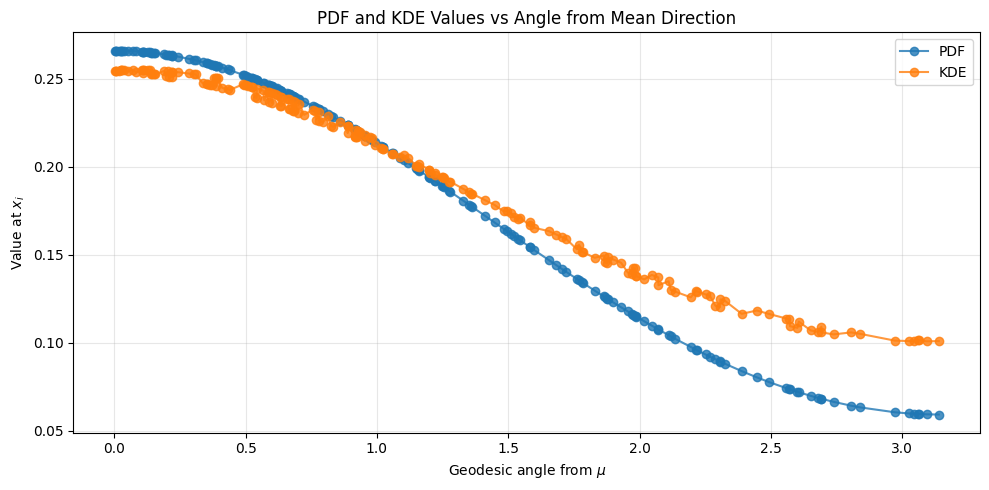

In [18]:
_, f_pdf, _ = weighted_distance_matrix_wrapped_normal_pdf(X, sigma = 1.5, mean_direction=[1,1])
_, f_kde, _ = weighted_distance_matrix_kde(X, h=0.7)

#order points by geodesic angle from the mean direction
mu = np.array([1.0, 1.0])
mu = mu / np.linalg.norm(mu)

X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)
theta = np.arccos(np.clip(X_unit @ mu, -1.0, 1.0))

order = np.argsort(theta)

plt.figure(figsize=(10, 5))
plt.plot(theta[order], f_pdf[order], 'o-', label='PDF', alpha=0.8)
plt.plot(theta[order], f_kde[order], 'o-', label='KDE', alpha=0.8)

plt.xlabel(r'Geodesic angle from $\mu$')
plt.ylabel(r'Value at $x_i$')
plt.title(r'PDF and KDE Values vs Angle from Mean Direction')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

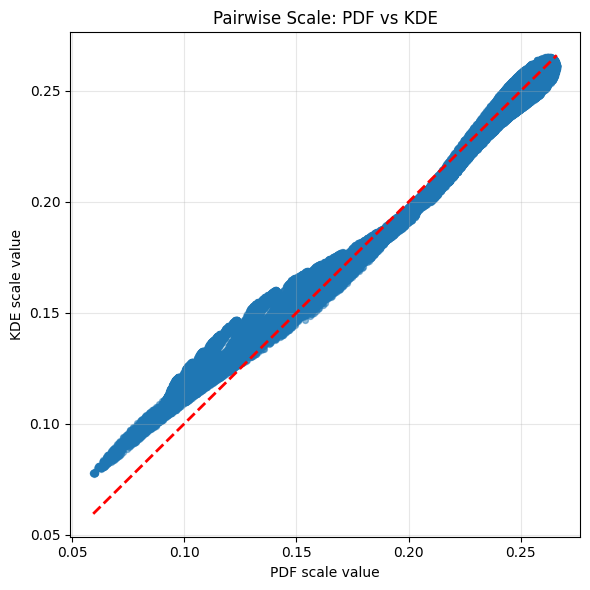

In [14]:
# Compute scales
_, _, scale_pdf = weighted_distance_matrix_wrapped_normal_pdf( X, sigma = 1.5, mean_direction=[1,1])

_, _, scale_kde = weighted_distance_matrix_kde(X, h=0.442)

# Use only upper triangle, excluding diagonal
i, j = np.triu_indices_from(scale_pdf, k=1)

x = scale_pdf[i, j]
y = scale_kde[i, j]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=18)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=2)

plt.xlabel('PDF scale value')
plt.ylabel('KDE scale value')
plt.title('Pairwise Scale: PDF vs KDE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Optimal h on this grid: 0.4420
Minimum MSE: 0.000086


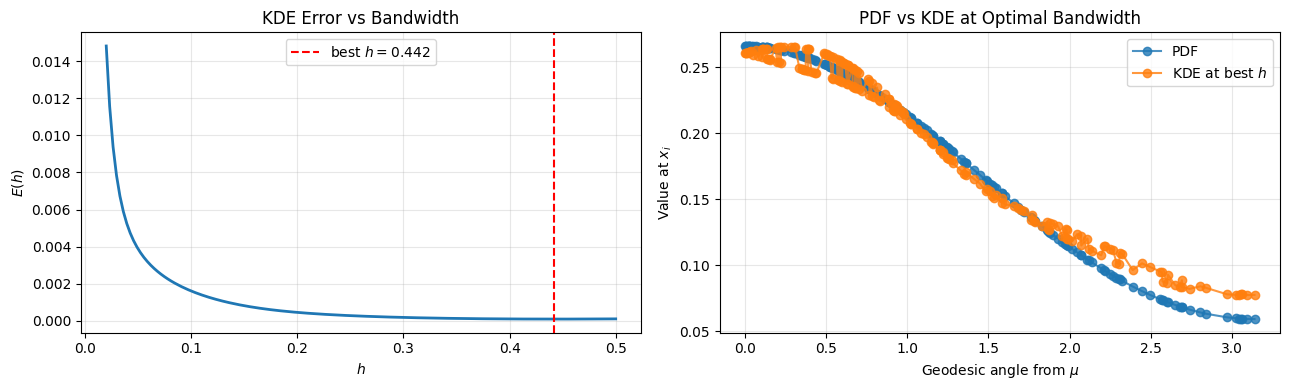

In [15]:
_, f_pdf, _ = weighted_distance_matrix_wrapped_normal_pdf(
    X,
    sigma=1.5,
    mean_direction=[1, 1],
)

# Grid of bandwidths to try
hs = np.linspace(0.02, 0.50, 150)

errors = []

for h in hs:
    _, f_kde, _ = weighted_distance_matrix_kde(X, h=h)
    err = np.mean((f_kde - f_pdf) ** 2)
    errors.append(err)

errors = np.array(errors)

# Best h on this grid
h_opt = hs[np.argmin(errors)]
print(f"Optimal h on this grid: {h_opt:.4f}")
print(f"Minimum MSE: {errors.min():.6f}")

# KDE at the chosen h
_, f_kde_opt, _ = weighted_distance_matrix_kde(X, h=h_opt)

# Order points by geodesic angle from the mean direction
mu = np.array([1.0, 1.0])
mu = mu / np.linalg.norm(mu)

X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)
theta = np.arccos(np.clip(X_unit @ mu, -1.0, 1.0))
order = np.argsort(theta)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Error as a function of h
ax[0].plot(hs, errors, lw=2)
ax[0].axvline(h_opt, color='red', linestyle='--', label=fr'best $h={h_opt:.3f}$')
ax[0].set_xlabel(r'$h$')
ax[0].set_ylabel(r'$E(h)$')
ax[0].set_title('KDE Error vs Bandwidth')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Compare PDF and KDE at the best h
ax[1].plot(theta[order], f_pdf[order], 'o-', label='PDF', alpha=0.8)
ax[1].plot(theta[order], f_kde_opt[order], 'o-', label=fr'KDE at best $h$', alpha=0.8)
ax[1].set_xlabel(r'Geodesic angle from $\mu$')
ax[1].set_ylabel(r'Value at $x_i$')
ax[1].set_title(r'PDF vs KDE at Optimal Bandwidth')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
